In [2]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

#Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
true_time=data['time']
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
times=data['time'].values/(1e9 * 60); times=times.astype(float);

#Restricts the timesteps of the data from timesteps0 to 140
data=data.isel(time=np.arange(0,140+1))
parcel=parcel.isel(time=np.arange(0,140+1))


# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# parcel=parcel.isel(time=np.arange(0,400+1))

currently on type general
currently on type cloudy
currently on type general
currently on type cloudy


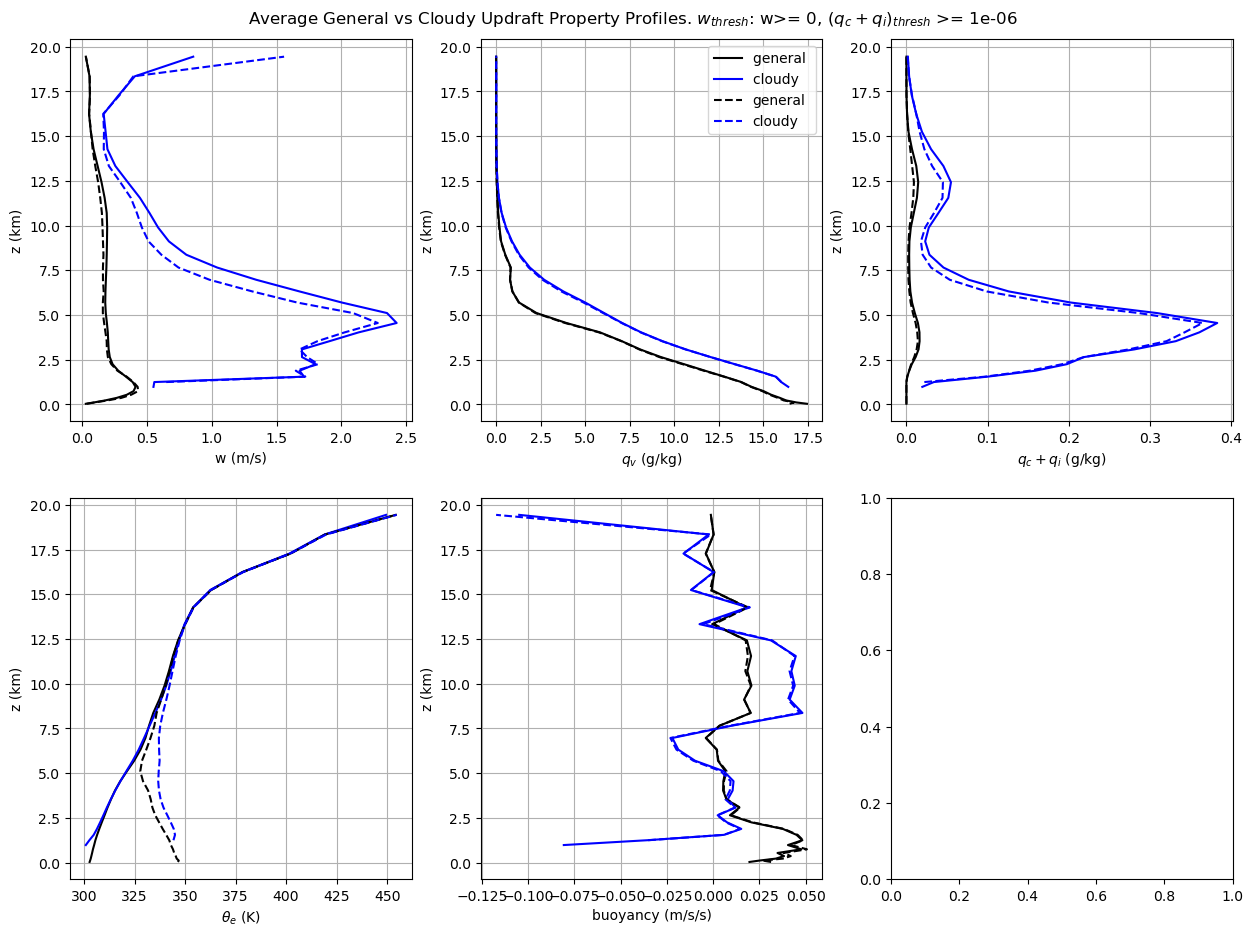

In [11]:
import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'
# dim='250m'
w_thresh=0; w_thresh=0.5 #m/s
qcqi_thresh=1e-6; qcqi_thresh=1e-9 #kg/kg

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle(f"Average General vs Cloudy Updraft Property Profiles. " + r"$w_{thresh}$: w>= " + f"{w_thresh}, " + r"$(q_c+q_i)_{thresh}$ >= " + f"{qcqi_thresh}")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()
plt.subplots_adjust(top=0.95)  # Adjust the top margin

####################################################################
#eulerian plotting
####################################################################
for type in ["general","cloudy"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='general':
            input_file = dir+f'tracking_algorithms/plots/job_out/1km_general_eulerian_profiles_wthresh{w_thresh}.h5'
        elif type=='cloudy':
            input_file = dir+f'tracking_algorithms/plots/job_out/1km_cloudy_eulerian_profiles_wthresh{w_thresh}.h5' 
    
    if dim=='250m':
        if type=='general':
            input_file = dir+f'tracking_algorithms/plots/job_out/250m_general_eulerian_profiles_wthresh{w_thresh}.h5' 
        elif type=='cloudy':
            input_file = dir+f'tracking_algorithms/plots/job_out/250m_cloudy_eulerian_profiles_wthresh{w_thresh}.h5' 
    
    with h5py.File(input_file, 'r') as f:
        profile_w = np.array(f['profile_w'])
        profile_qv = np.array(f['profile_qv'])
        profile_qc = np.array(f['profile_qc'])
        profile_qi = np.array(f['profile_qi'])
        profile_th = np.array(f['profile_th'])
        profile_buoyancy = np.array(f['profile_buoyancy'])

    #adding qc and qi profile together
    profile_qc[:,0]+=profile_qi[:,0] #for qi
    profile_qc[:,1]+=profile_qi[:,1] #for qi
    
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars=['w','qv','qc','th','buoyancy'] #qi
    # vars=['w'] #TESTING
    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)
    
    vars=['w','qv','qc','th','buoyancy'] 
    # vars=['w'] #TESTING
    axises=[ax1,ax2,ax3,ax4,ax5] #ax5
    xlabels=['w (m/s)',r'$q_v$ (g/kg)',r'$q_c + q_i$ (g/kg)',r'$\theta_e$ (K)','buoyancy (m/s/s)'] #qi (g/kg)
    for var,axis,xlabel in zip(vars,axises,xlabels):
        if type=='general':
            color='k'
        elif type=='cloudy':
            color='blue'
        plotting(globals()[f"out_{var}"],axis,label=type+' ',color=color)
        axis.set_ylabel('z (km)');axis.set_xlabel(xlabel);

        if axis==ax2:
            axis.legend(); #add legend

####################################################################
#lagrangian plotting
####################################################################
for type in ["general", "cloudy"]:
    print(f'currently on type {type}')

    if dim=='1km':
        if type=='general':
            input_file = dir+f'tracking_algorithms/plots/job_out/1km_general_lagrangian_profiles_wthresh{w_thresh}.h5'
        elif type=='cloudy':
            input_file = dir+f'tracking_algorithms/plots/job_out/1km_cloudy_lagrangian_profiles_wthresh{w_thresh}.h5' 
    
    if dim=='250m':
        if type=='general':
            input_file = dir+f'tracking_algorithms/plots/job_out/250m_general_lagrangian_profiles_wthresh{w_thresh}.h5' 
        elif type=='cloudy':
            input_file = dir+f'tracking_algorithms/plots/job_out/250m_cloudy_lagrangian_profiles_wthresh{w_thresh}.h5' 
    
    with h5py.File(input_file, 'r') as f:
        profile_w = np.array(f['profile_w'])
        profile_qv = np.array(f['profile_qv'])
        profile_qc = np.array(f['profile_qc'])
        profile_qi = np.array(f['profile_qi'])
        profile_th = np.array(f['profile_th'])
        profile_buoyancy = np.array(f['profile_buoyancy'])
            
    #adding qc and qi profile together
    profile_qc[:,0]+=profile_qi[:,0] 
    profile_qc[:,1]+=profile_qi[:,1] 

    for var in ['qv','qc']:
        globals()[f"profile_{var}"][:,0]*=1000
    
    # Plotting function
    def plotting(out_var, axis, label, color):
        axis.plot(out_var[:, 0], out_var[:, 1], label=label, color=color,linestyle='dashed')
        axis.grid(True)
    
    # Uses Averaged_Profiles Function
    vars = ['w', 'qv', 'qc', 'th','buoyancy']
    # vars = ['w']  # TESTING
    for var in vars:
        globals()[f"out_{var}"] = averaged_profiles(var)
    
    axises = [ax1, ax2, ax3, ax4, ax5]
    xlabels=['w (m/s)',r'$q_v$ (g/kg)',r'$q_c + q_i$ (g/kg)',r'$\theta_e$ (K)','buoyancy (m/s/s)'] #qi (g/kg)
    for var, axis, xlabel in zip(vars, axises, xlabels):
        if type == 'general':
            color = 'k'
        elif type == 'cloudy':
            color = 'blue'
        plotting(globals()[f"out_{var}"], axis, label=type, color=color)
        axis.set_ylabel('z (km)')
        axis.set_xlabel(xlabel)

        if axis==ax2:
            axis.legend()  # add legend

#save plot
if dim=='1km':
    plt.savefig(dir+f'tracking_algorithms/plots/1km_eulerian+lagrangian_generalvscloudy_updraft_profile_wthresh{w_thresh}.jpg', bbox_inches='tight', dpi=300) #uncomment if "general updrafts"
elif dim=='250m':
    plt.savefig(dir+f'tracking_algorithms/plots/250m_eulerian+lagrangian_generalvscloudy_updraft_profile_wthresh{w_thresh}.jpg', bbox_inches='tight', dpi=300) #uncomment if "general updrafts"

In [7]:
# #(CTRL) ------
# import h5py
# #Produced averaged profiles for plotting
# def averaged_profiles(var):
#     profile=globals()[f"profile_{var}"]

#     out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
#     out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
#     return out_var

# ####################################################################
# dim='1km'
# # dim='250m'

# #Uses Plotting Function 
# fig, axs = plt.subplots(2, 3, figsize=(15, 10))
# fig.suptitle(f"Average CTRL General vs Cloudy Updraft Property Profiles")
# ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()
# plt.subplots_adjust(top=0.95)  # Adjust the top margin

# ####################################################################
# #eulerian plotting
# ####################################################################
# for type in ["general","cloudy"]:
#     print(f'currently on type {type}')
    
#     if dim=='1km':
#         if type=='general':
#             input_file = dir+f'tracking_algorithms/plots/job_out/1km_general_eulerian_profiles_CTRL_wthresh{w_thresh}.h5'
#         elif type=='cloudy':
#             input_file = dir+f'tracking_algorithms/plots/job_out/1km_cloudy_eulerian_profiles_CTRL_wthresh{w_thresh}.h5' 
    
#     if dim=='250m':
#         if type=='general':
#             input_file = dir+f'tracking_algorithms/plots/job_out/250m_general_eulerian_profiles_CTRL_wthresh{w_thresh}.h5' 
#         elif type=='cloudy':
#             input_file = dir+f'tracking_algorithms/plots/job_out/250m_cloudy_eulerian_profiles_CTRL_wthresh{w_thresh}.h5' 
    
#     with h5py.File(input_file, 'r') as f:
#         profile_w = np.array(f['profile_w'])
#         profile_qv = np.array(f['profile_qv'])
#         profile_qc = np.array(f['profile_qc'])
#         profile_qi = np.array(f['profile_qi'])
#         profile_th = np.array(f['profile_th'])
#         profile_buoyancy = np.array(f['profile_buoyancy'])

#     #adding qc and qi profile together
#     profile_qc[:,0]+=profile_qi[:,0] #for qi
#     profile_qc[:,1]+=profile_qi[:,1] #for qi
    
#     #Plotting function
#     def plotting(out_var,axis,label,color):
#         axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
#         axis.grid(True)
    
#     #Uses Averaged_Profiles Function
#     vars=['w','qv','qc','th','buoyancy'] #qi
#     # vars=['w'] #TESTING
#     for var in vars:
#         globals()[f"out_{var}"]=averaged_profiles(var)
    
#     vars=['w','qv','qc','th','buoyancy'] 
#     # vars=['w'] #TESTING
#     axises=[ax1,ax2,ax3,ax4,ax5] #ax5
#     xlabels=['w (m/s)','qv (g/kg)','qc + qi (g/kg)','th (K)','buoyancy (m/s/s)'] #qi (g/kg)
#     for var,axis,xlabel in zip(vars,axises,xlabels):
#         if type=='general':
#             color='k'
#         elif type=='cloudy':
#             color='blue'
#         plotting(globals()[f"out_{var}"],axis,label=type+' ',color=color)
#         axis.set_ylabel('z (km)');axis.set_xlabel(xlabel);

#         if axis==ax2:
#             axis.legend(); #add legend

# ####################################################################
# #lagrangian plotting
# ####################################################################
# for type in ["general", "cloudy"]:
#     print(f'currently on type {type}')

#     if dim=='1km':
#         if type=='general':
#             input_file = dir+f'tracking_algorithms/plots/job_out/1km_general_lagrangian_profiles_CTRL_wthresh{w_thresh}.h5'
#         elif type=='cloudy':
#             input_file = dir+f'tracking_algorithms/plots/job_out/1km_cloudy_lagrangian_profiles_CTRL_wthresh{w_thresh}.h5' 
    
#     if dim=='250m':
#         if type=='general':
#             input_file = dir+f'tracking_algorithms/plots/job_out/250m_general_lagrangian_profiles_CTRL_wthresh{w_thresh}.h5' 
#         elif type=='cloudy':
#             input_file = dir+f'tracking_algorithms/plots/job_out/250m_cloudy_lagrangian_profiles_CTRL_wthresh{w_thresh}.h5' 
    
#     with h5py.File(input_file, 'r') as f:
#         profile_w = np.array(f['profile_w'])
#         profile_qv = np.array(f['profile_qv'])
#         profile_qc = np.array(f['profile_qc'])
#         profile_qi = np.array(f['profile_qi'])
#         profile_th = np.array(f['profile_th'])
#         profile_buoyancy = np.array(f['profile_buoyancy'])
            
#     #adding qc and qi profile together
#     profile_qc[:,0]+=profile_qi[:,0] 
#     profile_qc[:,1]+=profile_qi[:,1] 

#     for var in ['qv','qc']:
#         globals()[f"profile_{var}"][:,0]*=1000
    
#     # Plotting function
#     def plotting(out_var, axis, label, color):
#         axis.plot(out_var[:, 0], out_var[:, 1], label=label, color=color,linestyle='dashed')
#         axis.grid(True)
    
#     # Uses Averaged_Profiles Function
#     vars = ['w', 'qv', 'qc', 'th','buoyancy']
#     # vars = ['w']  # TESTING
#     for var in vars:
#         globals()[f"out_{var}"] = averaged_profiles(var)
    
#     axises = [ax1, ax2, ax3, ax4, ax5]
#     xlabels = ['w (m/s)', 'qv (g/kg)', 'qc + qi (g/kg)', 'th (K)', 'buoyancy (m/s/s)']
#     for var, axis, xlabel in zip(vars, axises, xlabels):
#         if type == 'general':
#             color = 'k'
#         elif type == 'cloudy':
#             color = 'blue'
#         plotting(globals()[f"out_{var}"], axis, label=type, color=color)
#         axis.set_ylabel('z (km)')
#         axis.set_xlabel(xlabel)

#         if axis==ax2:
#             axis.legend()  # add legend

# #save plot
# if dim=='1km':
#     plt.savefig(dir+f'tracking_algorithms/plots/1km_eulerian+lagrangian_generalvscloudy_updraft_profile_CTRL_wthresh{w_thresh}.jpg', bbox_inches='tight', dpi=300) #uncomment if "general updrafts"
# elif dim=='250m':
#     plt.savefig(dir+f'tracking_algorithms/plots/250m_eulerian+lagrangian_generalvscloudy_updraft_profile_CTRL_wthresh{w_thresh}.jpg', bbox_inches='tight', dpi=300) #uncomment if "general updrafts"

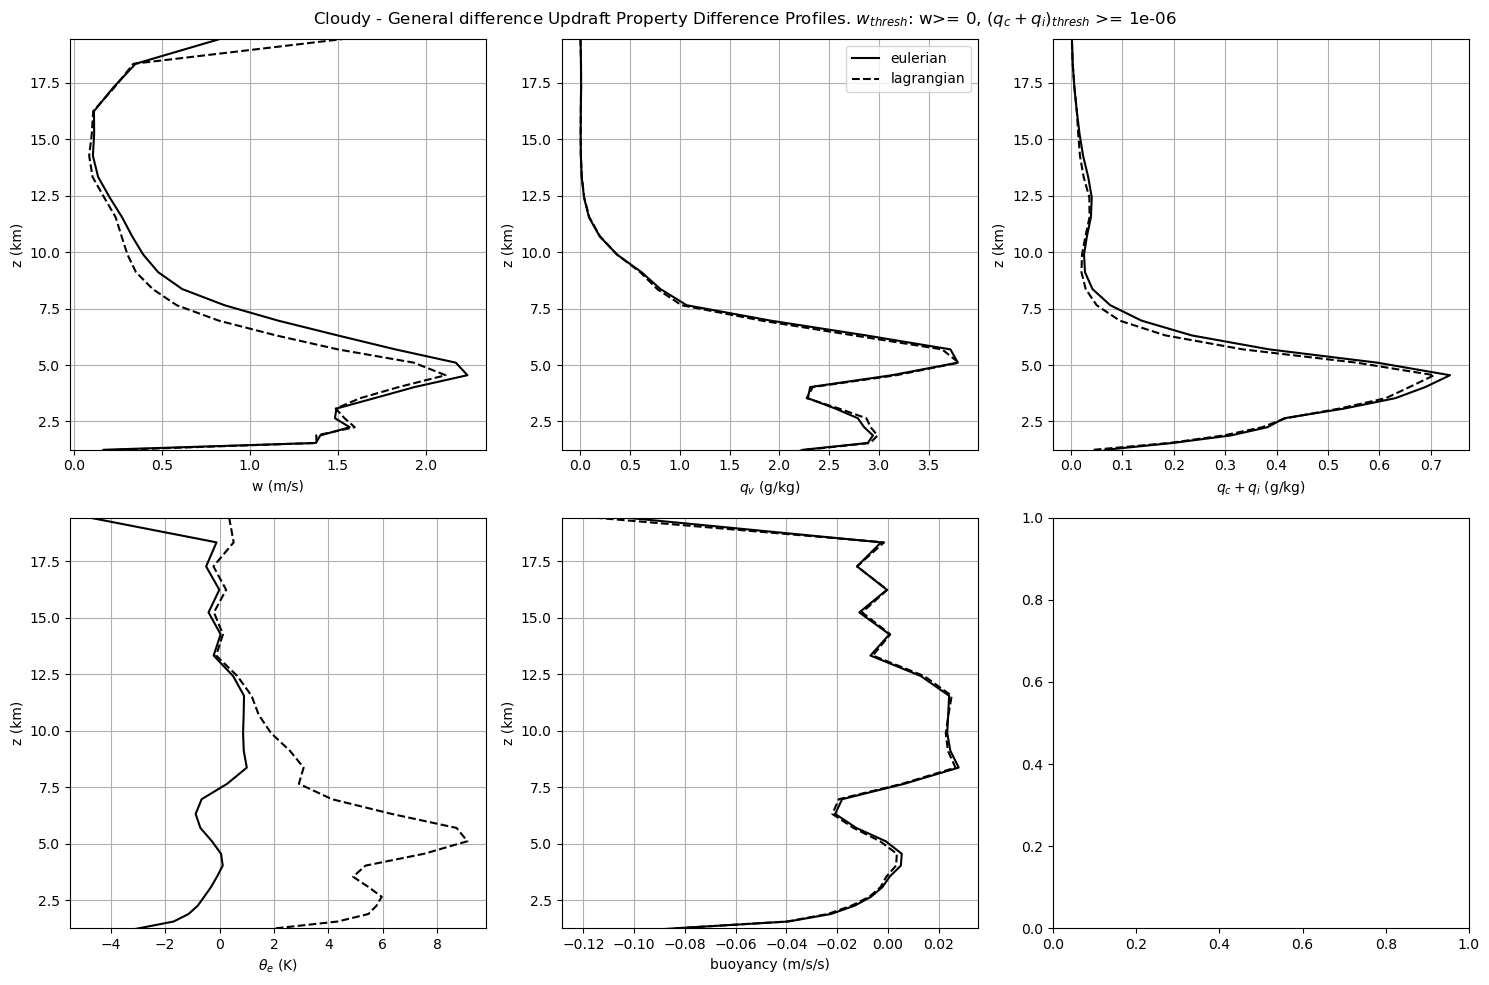

In [12]:
#Plotting Differences

#setting up figure
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle(f"Cloudy - General difference Updraft Property Difference Profiles. " + r"$w_{thresh}$: w>= " + f"{w_thresh}, " + r"$(q_c+q_i)_{thresh}$ >= " + f"{qcqi_thresh}")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

w_thresh=0; w_thresh=0.5 #m/s
qcqi_thresh=1e-6; qcqi_thresh=1e-9 #kg/kg

####################################################################
#eulerian plotting
####################################################################
def averaged_profiles(profile):
    out_var = profile[(profile[:, 1] != 0)]  # gets rid of rows that have no data
    out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
    return out_var

    
def get_data(type):
    if dim=='1km':
        if type=='general':
            input_file = dir+f'tracking_algorithms/plots/job_out/1km_general_eulerian_profiles_wthresh{w_thresh}.h5'
        elif type=='cloudy':
            input_file = dir+f'tracking_algorithms/plots/job_out/1km_cloudy_eulerian_profiles_wthresh{w_thresh}.h5'
    
    with h5py.File(input_file, 'r') as f:
        globals()[f'{type}_profile_w'] = np.array(f['profile_w'])
        globals()[f'{type}_profile_qv'] = np.array(f['profile_qv'])
        globals()[f'{type}_profile_qc'] = np.array(f['profile_qc'])
        globals()[f'{type}_profile_qi'] = np.array(f['profile_qi'])
        globals()[f'{type}_profile_th'] = np.array(f['profile_th'])
        globals()[f'{type}_profile_buoyancy'] = np.array(f['profile_buoyancy'])

    
def diff_plotting():

    #the plotting
    vars=['w','qv','qc','th','buoyancy']
    xlabels=['w (m/s)','qv (g/kg)','qc + qi (g/kg)','th (K)','buoyancy (m/s/s)']
    for xlabel,var in zip(xlabels,vars):
        
        if var=='w':axis=ax1
        if var=='qv':axis=ax2
        if var=='qc':axis=ax3
        if var=='th':axis=ax4
        if var=='buoyancy':axis=ax5

        #get profile
        types=['cloudy','general']
        get_data(types[0])
        out_var_one=globals()[f"{types[0]}_profile_{var}"]
        get_data(types[1])
        out_var_two=globals()[f"{types[1]}_profile_{var}"]

        #finding where cloudy updraft count goes below 10
        globals()[f'eulerian_cutofflow']=np.where(out_var_one[:,1]>10)[0][0]
        globals()[f'eulerian_cutoffhigh']=np.where(out_var_one[:,1]>10)[0][-1]

        #averaging
        out_var_one=averaged_profiles(out_var_one.copy())
        out_var_two=averaged_profiles(out_var_two.copy())

        #masking out non matches
        second_col_one = out_var_one[:, 1]
        second_col_two = out_var_two[:, 1]
        mask_one = np.isin(second_col_one, second_col_two)
        mask_two = np.isin(second_col_two, second_col_one)
        out_var_one = out_var_one.copy()[mask_one]
        out_var_two = out_var_two.copy()[mask_two]
        
        axis.plot(out_var_one[:,0]-out_var_two[:,0],out_var_one[:,1],color='k',label='eulerian')
        # axis.set_ylim(bottom=0,top=20)
        # axis.set_ylim(bottom=data['zh'][cutofflow],top=data['zh'][cutoffhigh])
        #labeling
        axis.set_ylabel('z (km)');axis.set_xlabel(xlabel);
        axis.grid(True)
        # axis.legend(fontsize='small') #only adds legend at final variable
    plt.tight_layout()
diff_plotting()



####################################################################
#lagrangian plotting
####################################################################
#Plotting Differences
def averaged_profiles(profile):
    out_var = profile[(profile[:, 1] != 0)]  # gets rid of rows that have no data
    out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
    return out_var

    
def get_data(type):
    if dim=='1km':
        if type=='general':
            input_file = dir+f'tracking_algorithms/plots/job_out/1km_general_lagrangian_profiles_wthresh{w_thresh}.h5'
        elif type=='cloudy':
            input_file = dir+f'tracking_algorithms/plots/job_out/1km_cloudy_lagrangian_profiles_wthresh{w_thresh}.h5'
    
    with h5py.File(input_file, 'r') as f:
        globals()[f'{type}_profile_w'] = np.array(f['profile_w'])
        globals()[f'{type}_profile_qv'] = np.array(f['profile_qv'])
        globals()[f'{type}_profile_qc'] = np.array(f['profile_qc'])
        globals()[f'{type}_profile_qi'] = np.array(f['profile_qi'])
        globals()[f'{type}_profile_th'] = np.array(f['profile_th'])
        globals()[f'{type}_profile_buoyancy'] = np.array(f['profile_buoyancy'])

    
def diff_plotting():

    #the plotting
    vars=['w','qv','qc','th','buoyancy']
    xlabels=['w (m/s)',r'$q_v$ (g/kg)',r'$q_c + q_i$ (g/kg)',r'$\theta_e$ (K)','buoyancy (m/s/s)'] #qi (g/kg)
    for xlabel,var in zip(xlabels,vars):
        
        if var=='w':axis=ax1
        if var=='qv':axis=ax2
        if var=='qc':axis=ax3
        if var=='th':axis=ax4
        if var=='buoyancy':axis=ax5

        #get profile
        types=['cloudy','general']
        get_data(types[0])
        out_var_one=globals()[f"{types[0]}_profile_{var}"]
        get_data(types[1])
        out_var_two=globals()[f"{types[1]}_profile_{var}"]

        #finding where cloudy updraft count goes below 10
        globals()[f'lagrangian_cutofflow']=np.where(out_var_one[:,1]>10)[0][0]
        globals()[f'lagrangian_cutoffhigh']=np.where(out_var_one[:,1]>10)[0][-1]

        
        cutofflow=np.min(np.array(globals()[f'eulerian_cutofflow'],globals()[f'lagrangian_cutofflow']))
        cutoffhigh=np.max(np.array(globals()[f'eulerian_cutoffhigh'],globals()[f'lagrangian_cutoffhigh']))

        #averaging
        out_var_one=averaged_profiles(out_var_one.copy())
        out_var_two=averaged_profiles(out_var_two.copy())

        #masking out non matches
        second_col_one = out_var_one[:, 1]
        second_col_two = out_var_two[:, 1]
        mask_one = np.isin(second_col_one, second_col_two)
        mask_two = np.isin(second_col_two, second_col_one)
        out_var_one = out_var_one.copy()[mask_one]
        out_var_two = out_var_two.copy()[mask_two]

        #converting kg/kg to g/kg
        if var=='qv' or var=='qc':
            out_var_one[:,0]*=1000
            out_var_two[:,0]*=1000
        
        axis.plot(out_var_one[:,0]-out_var_two[:,0],out_var_one[:,1],color='k',linestyle='dashed',label='lagrangian')
        # axis.set_ylim(bottom=0,top=20)
        axis.set_ylim(bottom=data['zh'][cutofflow],top=data['zh'][cutoffhigh])
        #labeling
        axis.set_ylabel('z (km)');axis.set_xlabel(xlabel);
        axis.grid(True)
        if axis==ax2:
            axis.legend()
    plt.tight_layout()


    #save plot
diff_plotting() 


plt.savefig(dir+f'tracking_algorithms/plots/1km_eulerian+lagrangian_updraft_profiles_diff_wthresh{w_thresh}.jpg', bbox_inches='tight', dpi=300) 

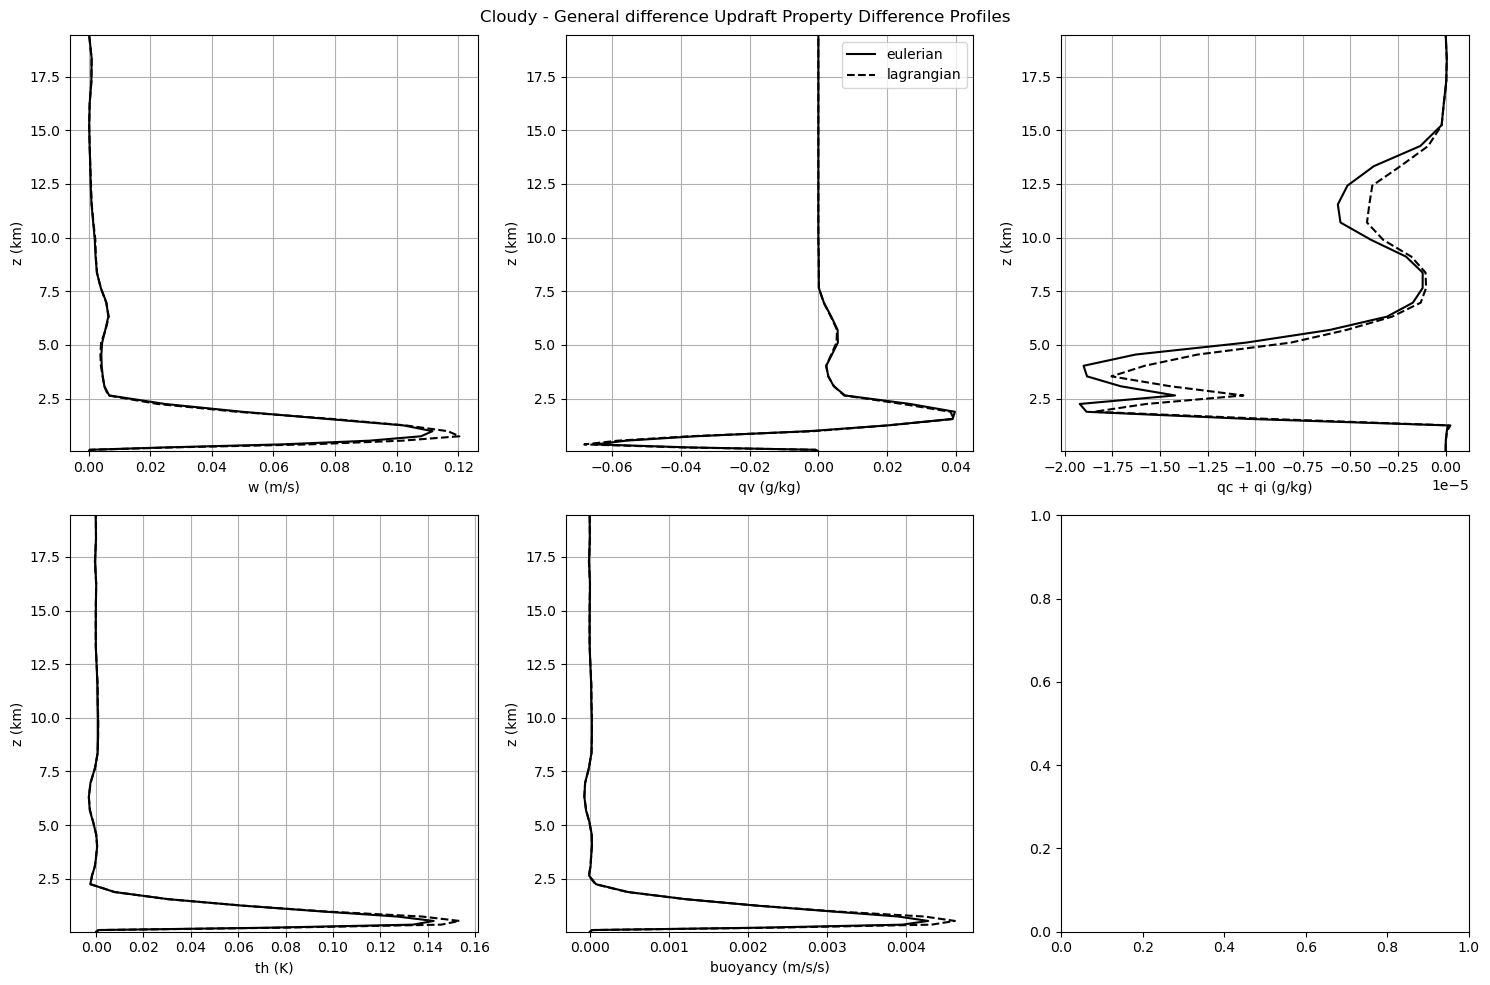

In [20]:
# #Plotting Differences CTRL ------

# #setting up figure
# fig, axs = plt.subplots(2, 3, figsize=(15, 10))
# fig.suptitle(f"Cloudy - General difference Updraft Property Difference Profiles")
# ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()


# ####################################################################
# #eulerian plotting
# ####################################################################
# def averaged_profiles(profile):
#     out_var = profile[(profile[:, 1] != 0)]  # gets rid of rows that have no data
#     out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
#     return out_var

    
# def get_data(type):
#     if dim=='1km':
#         if type=='general':
#             input_file = dir+f'tracking_algorithms/plots/job_out/1km_general_eulerian_profiles_CTRL_wthresh{w_thresh}.h5'
#         elif type=='cloudy':
#             input_file = dir+f'tracking_algorithms/plots/job_out/1km_cloudy_eulerian_profiles_CTRL_wthresh{w_thresh}.h5'
    
#     with h5py.File(input_file, 'r') as f:
#         globals()[f'{type}_profile_w'] = np.array(f['profile_w'])
#         globals()[f'{type}_profile_qv'] = np.array(f['profile_qv'])
#         globals()[f'{type}_profile_qc'] = np.array(f['profile_qc'])
#         globals()[f'{type}_profile_qi'] = np.array(f['profile_qi'])
#         globals()[f'{type}_profile_th'] = np.array(f['profile_th'])
#         globals()[f'{type}_profile_buoyancy'] = np.array(f['profile_buoyancy'])

    
# def diff_plotting():

#     #the plotting
#     vars=['w','qv','qc','th','buoyancy']
#     xlabels=['w (m/s)','qv (g/kg)','qc + qi (g/kg)','th (K)','buoyancy (m/s/s)']
#     for xlabel,var in zip(xlabels,vars):
        
#         if var=='w':axis=ax1
#         if var=='qv':axis=ax2
#         if var=='qc':axis=ax3
#         if var=='th':axis=ax4
#         if var=='buoyancy':axis=ax5

#         #get profile
#         types=['cloudy','general']
#         get_data(types[0])
#         out_var_one=globals()[f"{types[0]}_profile_{var}"]
#         get_data(types[1])
#         out_var_two=globals()[f"{types[1]}_profile_{var}"]

#         #finding where cloudy updraft count goes below 10
#         globals()[f'eulerian_cutofflow']=np.where(out_var_one[:,1]>10)[0][0]
#         globals()[f'eulerian_cutoffhigh']=np.where(out_var_one[:,1]>10)[0][-1]

#         #averaging
#         out_var_one=averaged_profiles(out_var_one.copy())
#         out_var_two=averaged_profiles(out_var_two.copy())

#         #masking out non matches
#         second_col_one = out_var_one[:, 1]
#         second_col_two = out_var_two[:, 1]
#         mask_one = np.isin(second_col_one, second_col_two)
#         mask_two = np.isin(second_col_two, second_col_one)
#         out_var_one = out_var_one.copy()[mask_one]
#         out_var_two = out_var_two.copy()[mask_two]
        
#         axis.plot(out_var_one[:,0]-out_var_two[:,0],out_var_one[:,1],color='k',label='eulerian')
#         # axis.set_ylim(bottom=0,top=20)
#         # axis.set_ylim(bottom=data['zh'][cutofflow],top=data['zh'][cutoffhigh])
#         #labeling
#         axis.set_ylabel('z (km)');axis.set_xlabel(xlabel);
#         axis.grid(True)
#         # axis.legend(fontsize='small') #only adds legend at final variable
#     plt.tight_layout()
# diff_plotting()



# ####################################################################
# #lagrangian plotting
# ####################################################################
# #Plotting Differences
# def averaged_profiles(profile):
#     out_var = profile[(profile[:, 1] != 0)]  # gets rid of rows that have no data
#     out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
#     return out_var

    
# def get_data(type):
#     if dim=='1km':
#         if type=='general':
#             input_file = dir+f'tracking_algorithms/plots/job_out/1km_general_lagrangian_profiles_CTRL_wthresh{w_thresh}.h5'
#         elif type=='cloudy':
#             input_file = dir+f'tracking_algorithms/plots/job_out/1km_cloudy_lagrangian_profiles_CTRL_wthresh{w_thresh}.h5'
    
#     with h5py.File(input_file, 'r') as f:
#         globals()[f'{type}_profile_w'] = np.array(f['profile_w'])
#         globals()[f'{type}_profile_qv'] = np.array(f['profile_qv'])
#         globals()[f'{type}_profile_qc'] = np.array(f['profile_qc'])
#         globals()[f'{type}_profile_qi'] = np.array(f['profile_qi'])
#         globals()[f'{type}_profile_th'] = np.array(f['profile_th'])
#         globals()[f'{type}_profile_buoyancy'] = np.array(f['profile_buoyancy'])

    
# def diff_plotting():

#     #the plotting
#     vars=['w','qv','qc','th','buoyancy']
#     xlabels=['w (m/s)','qv (g/kg)','qc + qi (g/kg)','th (K)','buoyancy (m/s/s)']
#     for xlabel,var in zip(xlabels,vars):
        
#         if var=='w':axis=ax1
#         if var=='qv':axis=ax2
#         if var=='qc':axis=ax3
#         if var=='th':axis=ax4
#         if var=='buoyancy':axis=ax5

#         #get profile
#         types=['cloudy','general']
#         get_data(types[0])
#         out_var_one=globals()[f"{types[0]}_profile_{var}"]
#         get_data(types[1])
#         out_var_two=globals()[f"{types[1]}_profile_{var}"]

#         #finding where cloudy updraft count goes below 10
#         globals()[f'lagrangian_cutofflow']=np.where(out_var_one[:,1]>10)[0][0]
#         globals()[f'lagrangian_cutoffhigh']=np.where(out_var_one[:,1]>10)[0][-1]

        
#         cutofflow=np.min(np.array(globals()[f'eulerian_cutofflow'],globals()[f'lagrangian_cutofflow']))
#         cutoffhigh=np.max(np.array(globals()[f'eulerian_cutoffhigh'],globals()[f'lagrangian_cutoffhigh']))

#         #averaging
#         out_var_one=averaged_profiles(out_var_one.copy())
#         out_var_two=averaged_profiles(out_var_two.copy())

#         #masking out non matches
#         second_col_one = out_var_one[:, 1]
#         second_col_two = out_var_two[:, 1]
#         mask_one = np.isin(second_col_one, second_col_two)
#         mask_two = np.isin(second_col_two, second_col_one)
#         out_var_one = out_var_one.copy()[mask_one]
#         out_var_two = out_var_two.copy()[mask_two]

#         #converting kg/kg to g/kg
#         if var=='qv' or var=='qc':
#             out_var_one[:,0]*=1000
#             out_var_two[:,0]*=1000
        
#         axis.plot(out_var_one[:,0]-out_var_two[:,0],out_var_one[:,1],color='k',linestyle='dashed',label='lagrangian')
#         # axis.set_ylim(bottom=0,top=20)
#         axis.set_ylim(bottom=data['zh'][cutofflow],top=data['zh'][cutoffhigh])
#         #labeling
#         axis.set_ylabel('z (km)');axis.set_xlabel(xlabel);
#         axis.grid(True)
#         if axis==ax2:
#             axis.legend()
#     plt.tight_layout()


#     #save plot
# diff_plotting() 


# plt.savefig(dir+f'tracking_algorithms/plots/1km_eulerian+lagrangian_updraft_profiles_diff_CTRL_wthresh{w_thresh}.jpg', bbox_inches='tight', dpi=300) 

In [ ]:
##########################################################

In [7]:
# # Current count is too low for lagrangian (10k vs 35k max)

# #Counts
# #Plotting counter column
# dim='1km'
# # dim='250m'

# #Uses CounterPlotting Function
# fig, axs = plt.subplots(1,1, figsize=(7,7))
# fig.suptitle(f"Average Eulerian + Lagrangian General vs Cloudy Updraft Property Profiles Count")
# # ax1 = axs.flatten()
# # plt.tight_layout()

# ####################################################################
# #eulerian plotting
# ####################################################################
# types=["general","cloudy"]
# for type in types:
#     print(f'currently on type {type}')
    
#     if dim=='1km':
#         if type=='general':
#             input_file = dir+'tracking_algorithms/plots/job_out/1km_general_eulerian_profiles_alljobs.h5'
#         elif type=='cloudy':
#             input_file = dir+'tracking_algorithms/plots/job_out/1km_cloudy_eulerian_profiles_alljobs.h5'
#     if dim=='250m':
#         if type=='general':
#             input_file = dir+'tracking_algorithms/plots/job_out/250m_general_eulerian_profiles_alljobs.h5'
#         elif type=='cloudy':
#             input_file = dir+'tracking_algorithms/plots/job_out/250m_cloudy_eulerian_profiles_alljobs.h5'
    
#     with h5py.File(input_file, 'r') as f:
#         profile_w = np.array(f['profile_w'])
#         profile_qv = np.array(f['profile_qv'])
#         profile_qc = np.array(f['profile_qc'])
#         profile_th = np.array(f['profile_th'])
        
#     def counter_plotting(out_var,axis,label,color):
#         out_var=out_var[ (out_var[:, 1] != 0)];
#         axis.plot(out_var[:,1],out_var[:,2],label=label,color=color)
#         axis.grid(True)
    
#     vars=['w']
#     axises=[axs]
#     xlabels=['# gridboxes profiled in z-level']
#     for var,axis,xlabel in zip(vars,axises,xlabels):
#         if type=='general':
#             color='k'
#         elif type=='cloudy':
#             color='blue'
#         counter_plotting(globals()[f"profile_{var}"],axis,label=type+' count',color=color)
#         axis.set_ylabel('z (km)');axis.set_xlabel(xlabel);
#         axis.legend();

# ####################################################################
# #lagrangian plotting
# ####################################################################
# types=["general","cloudy"]
# for type in types:
#     print(f'currently on type {type}')
    
#     # if dim=='1km':
#     #     if type=='general':
#     #         input_file = dir+'tracking_algorithms/plots/job_out/1km_general_eulerian_profiles_alljobs.h5'
#     #     elif type=='cloudy':
#     #         input_file = dir+'tracking_algorithms/plots/job_out/1km_cloudy_eulerian_profiles_alljobs.h5'
#     # if dim=='250m':
#     #     if type=='general':
#     #         input_file = dir+'tracking_algorithms/plots/job_out/250m_general_eulerian_profiles_alljobs.h5'
#     #     elif type=='cloudy':
#     #         input_file = dir+'tracking_algorithms/plots/job_out/250m_cloudy_eulerian_profiles_alljobs.h5'
    
#     # with h5py.File(input_file, 'r') as f:
#     #     profile_w = np.array(f['profile_w'])
#     #     profile_qv = np.array(f['profile_qv'])
#     #     profile_qc = np.array(f['profile_qc'])
#     #     profile_th = np.array(f['profile_th'])

    

#     if dim=='1km':
#         if type=='general':
#             input_file = dir+'tracking_algorithms/plots/job_out/1km_general_lagrangian_profiles_alljobs.h5'
#         elif type=='cloudy':
#             input_file = dir+'tracking_algorithms/plots/job_out/1km_cloudy_lagrangian_profiles_alljobs.h5' 
    
#     if dim=='250m':
#         if type=='general':
#             input_file = dir+'tracking_algorithms/plots/job_out/250m_general_lagrangian_profiles_alljobs.h5' 
#         elif type=='cloudy':
#             input_file = dir+'tracking_algorithms/plots/job_out/250m_cloudy_lagrangian_profiles_alljobs.h5' 
    
#     with h5py.File(input_file, 'r') as f:
#         profile_w = np.array(f['profile_w'])
#         profile_qv = np.array(f['profile_qv'])
#         profile_qc = np.array(f['profile_qc'])
#         profile_qi = np.array(f['profile_qi'])
#         profile_th = np.array(f['profile_th'])
#         profile_buoyancy = np.array(f['profile_buoyancy'])



#     def counter_plotting(out_var,axis,label,color):
#         out_var=out_var[ (out_var[:, 1] != 0)];
#         axis.plot(out_var[:,1],out_var[:,2],label=label,color=color)
#         axis.grid(True)

#         # print(np.sum(out_var[:,1])) #TESTING
    
#     vars=['w']
#     axises=[axs]
#     xlabels=['# parcels profiled in z-level']
#     for var,axis,xlabel in zip(vars,axises,xlabels):
#         if type=='general':
#             color='k'
#         elif type=='cloudy':
#             color='blue'
#         counter_plotting(globals()[f"profile_{var}"],axis,label=type+' count',color=color)
#         axis.set_ylabel('z (km)');axis.set_xlabel(xlabel);
#         axis.legend();
#     ############################# 
    
#     #save plot
#     dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
#     if dim=='1km':
#         plt.savefig(dir+'tracking_algorithms/plots/1km_eulerian+lagrangian_generalvscloudy_updraft_profile_counter.jpg', bbox_inches='tight', dpi=300) 
#     if dim=='250m':
#         plt.savefig(dir+'tracking_algorithms/plots/250m_eulerian+lagrangian_generalvscloudy_updraft_profile_counter.jpg', bbox_inches='tight', dpi=300) 